# Titanic: Exploratory Data Analysis & Survival Prediction

## Project Overview

This project investigates the Kaggle Titanic passenger dataset with the objective of understanding the data and determining which factors are associated with passenger survival.

The analysis follows a structured data science workflow, beginning with data inspection and validation before progressing to exploratory analysis, preprocessing, feature engineering, and predictive modelling where justified by the findings.

Rather than assuming a particular modelling or preprocessing approach in advance, decisions throughout the project will be driven by observations made during the analysis.

## Objectives

- **Understand the dataset:** Establish the structure, meaning, types, and distributions of the available variables.
- **Assess data quality:** Identify missing values, inconsistencies, unusual observations, duplicates, and potential data-quality issues.
- **Explore relationships:** Investigate patterns and relationships between variables and passenger survival.
- **Prepare the data:** Determine what preprocessing and feature transformations are justified by the analysis.
- **Model the target:** Establish appropriate baseline models and evaluate whether more sophisticated approaches provide meaningful improvement.

## Dataset Dictionary

| Feature      | Definition                     | Key / Values                                             |
| :----------- | :----------------------------- | :------------------------------------------------------- |
| **Survived** | Target variable                | `0` = No, `1` = Yes                                      |
| **Pclass**   | Ticket class                   | `1` = 1st (Upper), `2` = 2nd (Middle), `3` = 3rd (Lower) |
| **Sex**      | Passenger sex                  |                                                          |
| **Age**      | Age in years                   | Fractional if < 1. If the age is estimated, is it in the form of xx.5 |
| **SibSp**    | # of siblings / spouses aboard |                                                          |
| **Parch**    | # of parents / children aboard |                                                          |
| **Ticket**   | Ticket number                  |                                                          |
| **Fare**     | Passenger fare                 |                                                          |
| **Cabin**    | Cabin number                   |                                                          |
| **Embarked** | Port of Embarkation            | `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton     |


## 1. Structural Inspection and Data Validation

This section establishes an initial understanding of the datasets and assesses their data quality before exploratory analysis.

The following will be assessed:

1. Load the training and test datasets.
2. Inspect the dimensions, structure, and data types of each dataset.
3. Examine the number and distribution of unique values in each variable.
4. Identify and investigate missing values.
5. Check for duplicate observations.
6. Validate that observed values conform to the definitions and constraints provided in the dataset documentation.
7. Identify potentially anomalous or suspicious observations requiring further investigation.
8. Produce descriptive statistics for numerical variables.
9. Examine the distribution of the target variable in the training dataset.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [3]:
print(f"Train Set Shape: {train_df.shape} (Rows, Columns)")
print(f"Test Set Shape:  {test_df.shape} (Rows, Columns)")

print("\n--- Training Data Types & Non-Null Counts ---")
train_df.info()

print("\n--- Test Data Types & Non-Null Counts ---")
test_df.info()

print("\n--- Train Data Sample ---")
display(train_df.head())

Train Set Shape: (891, 12) (Rows, Columns)
Test Set Shape:  (418, 11) (Rows, Columns)

--- Training Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

--- Test Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
inspection = pd.DataFrame({
    "dtype": train_df.dtypes,
    "n_unique": train_df.nunique(),
    "unique_pct": train_df.nunique() / len(train_df) * 100,
    "n_missing": train_df.isna().sum(),
    "missing_pct": train_df.isna().mean() * 100
})

display(inspection)

,dtype,n_unique,unique_pct,n_missing,missing_pct
PassengerId,int64,891,100.000000,0,0.000000
Survived,int64,2,0.224467,0,0.000000
Pclass,int64,3,0.336700,0,0.000000
Name,str,891,100.000000,0,0.000000
Sex,str,2,0.224467,0,0.000000
Age,float64,88,9.876543,177,19.865320
SibSp,int64,7,0.785634,0,0.000000
Parch,int64,7,0.785634,0,0.000000
Ticket,str,681,76.430976,0,0.000000
Fare,float64,248,27.833895,0,0.000000


### Initial Observations

`PassengerId`

100% unique.

Questions:
- Is this just an identifier with no relevance as a predictive feature

`Name`

100% unique. 

Questions:
- Is the raw name useful
- Does it contain structured information that could potentially be extracted?

`Ticket`

681 unique values out of 891.

Questions:
- Why are some tickets shared by multiple passengers

`Cabin`

Only 204 non-null observations.

Questions: 
- Is the missingness random,
- Does it relate to passenger characteristics such as class?

`Age`

177 missing

Questions:
- What does the distribution look like
- Is there a sensible way to handle missing values

### Missing values

In [5]:
def missing_values_table(df: pd.DataFrame, name: str="Dataset"):
    missing_count = df.isnull().sum()
    missing_pct = 100 * (missing_count / len(df))
    
    missing_table = pd.concat([missing_count, missing_pct], axis=1)
    missing_table.columns = ['Missing Values', '% of Total Values']
    
    # Filter to show only features with missing values
    missing_table = missing_table[missing_table['Missing Values'] > 0]
    missing_table = missing_table.sort_values('% of Total Values', ascending=False).round(2)
    
    print(f"--- Missing Values Summary ({name}) ---")
    if missing_table.empty:
        print("No missing values found.\n")
    else:
        display(missing_table)
        print("-" * 50)

missing_values_table(train_df, "Train Set")
missing_values_table(test_df, "Test Set")

--- Missing Values Summary (Train Set) ---


,Missing Values,% of Total Values
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


--------------------------------------------------
--- Missing Values Summary (Test Set) ---


,Missing Values,% of Total Values
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


--------------------------------------------------


### Missing Data Observations

The missing value analysis indetified the following:

   * **`Cabin`:** ~77% missing in train, ~78% missing in test.
   * **`Age`:** ~20% missing in train, ~20% missing in test.
   * **`Embarked`:** Only 2 missing values in train.
   * **`Fare`:** 1 missing value in test.

   This shows that the missingness is consistent across both train and test sets.

### Duplicate values

Earlier analysis showed that both `PassengerId` and `Name` in the training set were 100% unique. However, as a sanity check it is still included.

In [6]:
print(f"Duplicate rows in train: {train_df.duplicated().sum()}")
print(f"Duplicate rows in test:  {test_df.duplicated().sum()}")

Duplicate rows in train: 0
Duplicate rows in test:  0


### Data Dictionary Validation

In [7]:
expected_values = {
    "Pclass": {"1", "2", "3"},
    "Survived": {"0", "1"},
    "Sex": {"male", "female"},
    "Embarked": {"C", "Q", "S"}
}

validation_rows = []

for column, expected in expected_values.items():
    observed = set(train_df[column].dropna().astype(str).unique())

    validation_rows.append({
        "Variable": column,
        "Observed Values": ", ".join(sorted(observed)),
        "Expected Values": ", ".join(sorted(expected)),
        "Valid": observed.issubset(expected)
    })

validation = pd.DataFrame(validation_rows)

display(validation)

,Variable,Observed Values,Expected Values,Valid
0,Pclass,"1, 2, 3","1, 2, 3",True
1,Survived,"0, 1","0, 1",True
2,Sex,"female, male","female, male",True
3,Embarked,"C, Q, S","C, Q, S",True


### Observations

Data matches the expected values. `Survived` contains only 0 and 1, confirming that the target is binary and that the predictive task can be framed as binary classification.

### Summary statistics for numerical columns

In [8]:
numeric_columns = ["Age", "SibSp", "Parch", "Fare"]

display(train_df[numeric_columns].describe())

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


### Observations

- `Age` ranges from approximately 0.4 to 80 years, with no immediately apparent impossible values. Missingness has already been identified and will be investigated during exploratory analysis.
- `SibSp` ranges from 0 to 8 and contains no negative values.
- `Parch` ranges from 0 to 6 and contains no negative values.
- `Fare` ranges from 0 to approximately 512. The mean is substantially higher than the median, suggesting a potentially skewed distribution that warrants further investigation.
- A fare of 0 is present and should be investigated to determine whether this represents a valid observation or a data-quality issue.
- No immediately apparent numerical values violate the expected ranges described by the dataset documentation.

## Data Quality Summary

The initial structural inspection and validation established the following:

- The training dataset contains 891 observations and 12 variables, while the test dataset contains 418 observations and 11 variables.
- `Survived` is present only in the training dataset and contains two values (`0` and `1`), establishing a binary classification target.
- `PassengerId` is unique across both datasets, and no exact duplicate records were identified.
- The observed categorical values conform to the dataset documentation.
- Missing values are present in `Cabin`, `Age`, `Embarked`, and `Fare`.
- `Cabin` has substantial missingness, while `Embarked` and `Fare` have very limited missing observations.
- The numerical variables do not contain any immediately apparent values that violate their expected ranges.
- `Fare` contains a zero value and a relatively large maximum compared with its median, warranting further investigation during exploratory analysis.

These findings define the areas requiring further investigation during exploratory analysis and will inform subsequent data preparation decisions.

# 2 Univariate Analysis

### 2.1 Target Variable: Survived

The target variable represents whether a passenger survived the Titanic disaster.

- `0` = Did not survive
- `1` = Survived

The distribution of the target will be examined to determine the class balance of the dataset and establish an initial understanding of the prediction problem.

In [9]:
survival_counts = train_df["Survived"].value_counts().sort_index()
survival_pct = train_df["Survived"].value_counts(normalize=True).sort_index() * 100

survival_summary = pd.DataFrame({
    "Count": survival_counts,
    "Percentage": survival_pct.round(2)
})

display(survival_summary)

,Count,Percentage
Survived,,
0,549,61.62
1,342,38.38


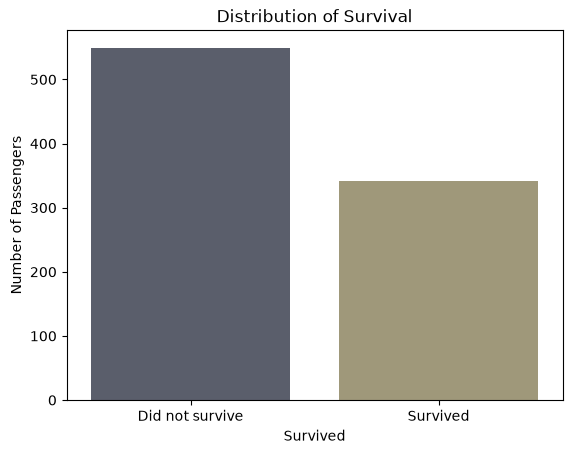

In [10]:
sns.countplot(
    data=train_df,
    x="Survived",
    palette="cividis",
    hue="Survived",
    legend=False
)

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did not survive", "Survived"], rotation=0)

plt.show()


### Observations

- The target contains two classes: survived and did not survive.
- The classes are not evenly distributed, with 61.62% of passengers not surviving and 38.38% surviving.
- The target therefore exhibits moderate class imbalance.

### 2.2 Categorical Variables

The categorical variables are examined individually to understand their observed categories and frequency distributions.

The analysis focuses on the observed frequency of each category rather than relationships with the target variable, which will be addressed during bivariate analysis.

In [11]:
categorical_columns = ["Sex", "Embarked"]

for column in categorical_columns:
    print(f"--- {column} ---")
    
    summary = pd.DataFrame({
        "Count": train_df[column].value_counts(dropna=False),
        "Percentage": (
            train_df[column]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })
    
    display(summary)

--- Sex ---


,Count,Percentage
Sex,,
male,577,64.76
female,314,35.24


--- Embarked ---


,Count,Percentage
Embarked,,
S,644,72.28
C,168,18.86
Q,77,8.64
NaN,2,0.22


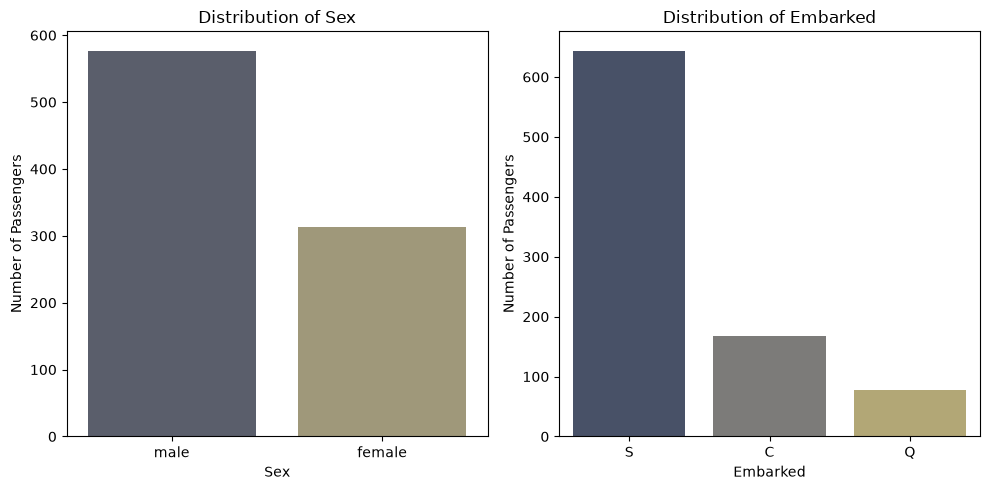

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, column in zip(axes, categorical_columns):
    counts = train_df[column].value_counts(dropna=False).reset_index()
    counts.columns = [column, "Number of Passengers"]

    sns.barplot(
        data = counts,
        x=column,
        y="Number of Passengers",
        errorbar=None,
        palette="cividis",
        hue=column,
        legend=False,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

### Observations

**Sex:**
- Male is the more common sex, representing approximately 65% of passengers.
- The distribution is moderately imbalanced, with females representing approximately 35% of passengers.

**Embarked:**
- `'S'` is by far the most common embarkation port, accounting for approximately 72% of passengers.
- `'C'` accounts for approximately 19% of passengers.
- `'Q'` is the least common, accounting for approximately 9% of passengers.
- Two observations are missing an `Embarked` value.

**Overall:**
- Both variables have low cardinality, with two categories for `Sex` and three categories for `Embarked`.

### 2.3 Discrete Numerical Variables

`Pclass`, `SibSp`, and `Parch` are represented numerically but contain a relatively small number of discrete values.

These variables will therefore be examined using frequency distributions rather than treating them as continuous variables.

In [13]:
discrete_columns = ["Pclass", "SibSp", "Parch"]

for column in discrete_columns:
    print(f"--- {column} ---")
    
    summary = pd.DataFrame({
        "Count": train_df[column].value_counts().sort_index(),
        "Percentage": (
            train_df[column]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })
    
    display(summary)

--- Pclass ---


,Count,Percentage
Pclass,,
1,216,24.24
2,184,20.65
3,491,55.11


--- SibSp ---


,Count,Percentage
SibSp,,
0,608,68.24
1,209,23.46
2,28,3.14
3,16,1.80
4,18,2.02
5,5,0.56
8,7,0.79


--- Parch ---


,Count,Percentage
Parch,,
0,678,76.09
1,118,13.24
2,80,8.98
3,5,0.56
4,4,0.45
5,5,0.56
6,1,0.11


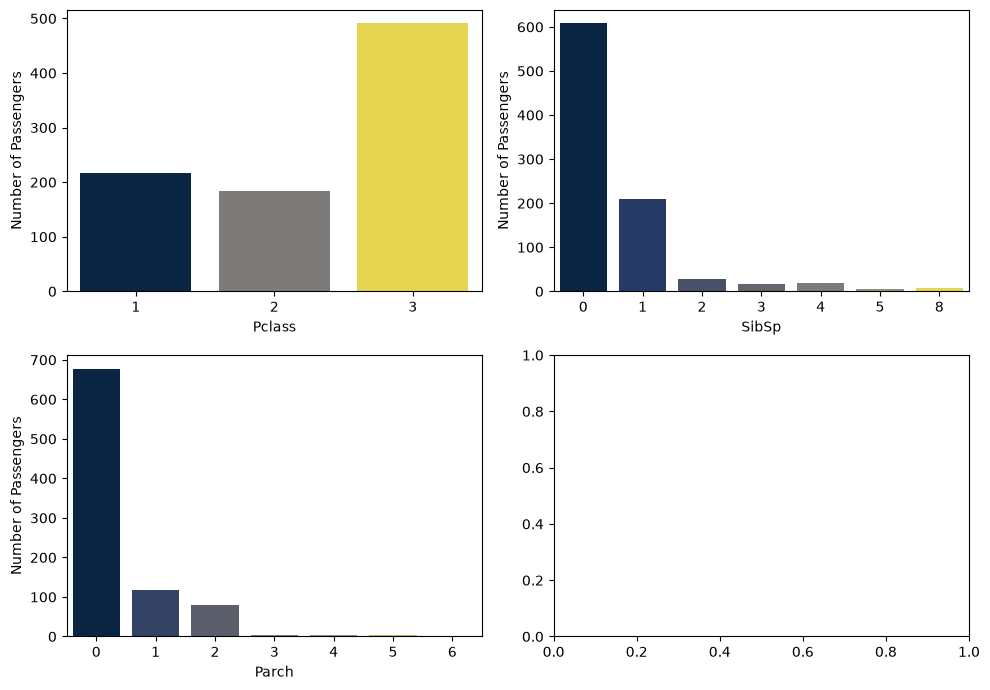

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, column in zip(axes.flat, discrete_columns):
    counts = train_df[column].value_counts().sort_index().reset_index()
    counts.columns = [column, "Number of Passengers"]

    sns.barplot(
        data=counts,
        x=column,
        y="Number of Passengers",
        hue=column,
        legend=False,
        palette="cividis",
        ax=ax
    )

plt.tight_layout()
plt.show()